In [2]:
%matplotlib inline
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [12]:
(X_train, y_train), (X_test, y_test)= datasets.cifar10.load_data()
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [26]:
def generate_plot(x, y ,index):
    plt.figure(figsize=[3,3])
    plt.imshow(x[index])
    plt.xlabel(labels[y[index][0]])
    

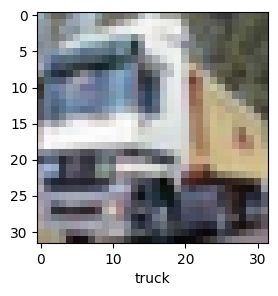

In [27]:
# plt.figure(figsize=[2,2])
# plt.imshow(X_train[1])
# y_train[1]
# labels[y_train[1][0]]

generate_plot(X_train, y_train, 1)


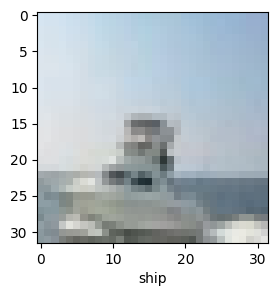

In [28]:
generate_plot(X_train, y_train, 100)

In [32]:
### Normalizing data between 0 and 1 for pixel vals between 0-255

X_train = X_train / 255.0
X_test = X_test / 255.0

In [33]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.3539 - loss: 1.8143
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.4268 - loss: 1.6233
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.4588 - loss: 1.5421
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.4777 - loss: 1.4826
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.4972 - loss: 1.4332


In [34]:
cnn = models.Sequential([
    #CNN - feature extraction
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    #Dense - classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(X_train, y_train, epochs=10)

c:\Users\premt\OneDrive\Desktop\Programming\Portfolio\ml-algorithms\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4767 - loss: 1.4524
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6100 - loss: 1.1095
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6535 - loss: 0.9936
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6812 - loss: 0.9168
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6983 - loss: 0.8616
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7189 - loss: 0.8089
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7334 - loss: 0.7631
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.7493 - loss: 0.7210
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7598 - loss: 0.6878
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7744 - loss: 0.6489


In [ ]:
### CNN achieved mosre accuracy in 5 epochs than the ANN 

cnn.evaluate(X_test, y_test)
### 68% prediction accuracy on the test set for the CNN

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6815 - loss: 0.9544


[0.9544302821159363, 0.6815000176429749]

In [39]:
y_pred = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [40]:
y_pred[:5]

array([[3.50950076e-03, 2.70763674e-04, 3.40402662e-03, 9.51142848e-01,
        2.49936624e-04, 1.58972386e-02, 3.64792184e-03, 3.30888215e-05,
        2.17940025e-02, 5.06859724e-05],
       [2.38349559e-04, 3.11200708e-01, 5.76535570e-07, 4.38041025e-06,
        1.47040833e-08, 9.91355442e-09, 9.72705738e-09, 1.24129318e-09,
        6.86407804e-01, 2.14818912e-03],
       [8.54697078e-03, 2.26829275e-02, 1.88546313e-04, 2.96260882e-03,
        2.48048251e-04, 3.26387817e-05, 4.33472678e-06, 1.54056193e-04,
        9.59497690e-01, 5.68220671e-03],
       [9.58203077e-01, 1.41821231e-03, 2.05253027e-02, 8.11552454e-04,
        1.09047685e-02, 4.87021566e-07, 2.04911303e-05, 2.56107742e-04,
        7.51130935e-03, 3.48582369e-04],
       [1.32398418e-06, 2.39302735e-05, 4.11519706e-02, 4.26512621e-02,
        2.74685085e-01, 4.15933831e-03, 6.37307465e-01, 8.14843588e-06,
        9.80210007e-06, 1.64925007e-06]], dtype=float32)

In [41]:
y_labels = [np.argmax(prob) for prob in y_pred]
y_labels[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

'frog'

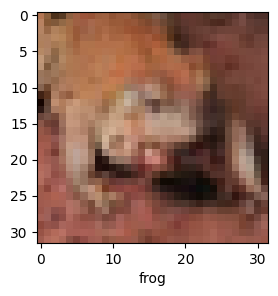

In [ ]:
# correct prediction

generate_plot(X_test, y_test, 5)
labels[y_labels[4]]

'ship'

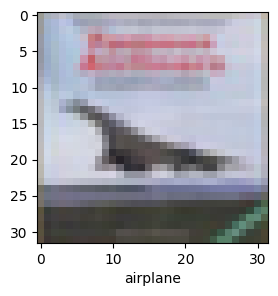

In [ ]:
# wrong prediction

generate_plot(X_test, y_test, 3)
labels[y_labels[2]]